# Hierarchical Forecasting
- Simulate 2 categories, 3 products each
- Compare bottom-up vs direct category forecast

Requirements: pandas, numpy, matplotlib, statsmodels

In [17]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")

np.random.seed(42)

In [13]:
# Metrics

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-9, y_true))) * 100
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'WMAPE(%)': wmape}

In [14]:
# -----------------------------
# 1. Generate Hierarchical Data
# -----------------------------
def generate_hierarchy():
    dates = pd.date_range("2022-01-01", periods=600, freq="D")
    categories = ["A", "B"]
    products = ["P1", "P2", "P3"]
    rows = []

    for cat in categories:
        for prod in products:
            t = np.arange(len(dates))
            trend = 0.01 * t
            seasonal = 5 * np.sin(2*np.pi*t/7)
            base = 50 if cat == "A" else 40
            noise = np.random.normal(0, 3, len(dates))
            sales = base + trend + seasonal + noise + np.random.randint(0,10)
            for i in range(len(dates)):
                rows.append([dates[i], cat, prod, sales[i]])

    return pd.DataFrame(rows, columns=["ds","category","product","y"])

df = generate_hierarchy()

H = 30
train = df[df["ds"] <= df["ds"].max() - pd.Timedelta(days=H)]
test = df[df["ds"] > df["ds"].max() - pd.Timedelta(days=H)]

In [15]:
# -----------------------------
# 3. Bottom-Up Forecast
# -----------------------------
bottom_results = []

for (cat, prod), group in train.groupby(["category","product"]):
    model = SARIMAX(group["y"], order=(1,1,1), seasonal_order=(1,1,1,7),
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=H)
    mean = np.asarray(fc.predicted_mean)
    conf = fc.conf_int(alpha=0.05)
    if isinstance(conf, pd.DataFrame):
        lower = conf.iloc[:,0].values
        upper = conf.iloc[:,1].values
    else:
        lower = conf[:,0]
        upper = conf[:,1]
    var = ((upper - mean) / 1.96)**2  # approximate variance

    for i in range(H):
        bottom_results.append([
            test["ds"].unique()[i], cat, prod,
            mean[i], var[i]
        ])

bottom_df = pd.DataFrame(bottom_results,
                         columns=["ds","category","product","mean","var"])

# Aggregate bottom-up
bottom_cat = bottom_df.groupby(["ds","category"]).agg(
    mean=("mean","sum"),
    var=("var","sum")
).reset_index()

bottom_cat["lower"] = bottom_cat["mean"] - 1.96*np.sqrt(bottom_cat["var"])
bottom_cat["upper"] = bottom_cat["mean"] + 1.96*np.sqrt(bottom_cat["var"])

# -----------------------------
# 4. Direct Category Forecast
# -----------------------------
direct_results = []

for cat, group in train.groupby("category"):
    cat_series = group.groupby("ds")["y"].sum()
    model = SARIMAX(cat_series, order=(1,1,1), seasonal_order=(1,1,1,7),
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=H)
    mean = np.asarray(fc.predicted_mean)
    conf = fc.conf_int(alpha=0.05)
    if isinstance(conf, pd.DataFrame):
        lower = conf.iloc[:,0].values
        upper = conf.iloc[:,1].values
    else:
        lower = conf[:,0]
        upper = conf[:,1]

    for i in range(H):
        direct_results.append([
            test["ds"].unique()[i], cat,
            mean[i], lower[i], upper[i]
        ])

direct_df = pd.DataFrame(direct_results,
                         columns=["ds","category","mean","lower","upper"])

# -----------------------------
# 5. Comparing
# -----------------------------
def compare_category_metrics(cat):
    # actual aggregated by date for the category
    actual = test[test["category"] == cat].groupby("ds")["y"].sum().reset_index().rename(columns={"y": "actual"})
    # bottom-up preds for this category (mean, lower, upper)
    bottom_c = bottom_cat[bottom_cat["category"] == cat][["ds", "mean", "lower", "upper"]].rename(
        columns={"mean": "bottom_mean", "lower": "bottom_lower", "upper": "bottom_upper"}
    )
    # direct category preds (mean, lower, upper)
    direct_c = direct_df[direct_df["category"] == cat][["ds", "mean", "lower", "upper"]].rename(
        columns={"mean": "direct_mean", "lower": "direct_lower", "upper": "direct_upper"}
    )

    # merge on ds to ensure aligned comparisons
    merged = actual.merge(bottom_c, on="ds", how="inner").merge(direct_c, on="ds", how="inner")

    # sanity: lengths should match H (or the intersection length)
    print(f"Comparing category {cat}: aligned evaluation length = {len(merged)} days")

    # compute metrics (arrays are aligned by construction)
    bottom_metrics = metrics(merged["actual"].values, merged["bottom_mean"].values)
    direct_metrics = metrics(merged["actual"].values, merged["direct_mean"].values)

    # prepare metrics table
    results = {
        "Bottom-Up": bottom_metrics,
        "Direct": direct_metrics
    }
    summary = pd.DataFrame(results).T
    display(summary.round(3))

    # also show merged head for debugging/inspection
    display(merged.head(10))

    return merged, summary

# Run for category A (and B if you want)
merged_A, summary_A = compare_category_metrics("A")
merged_B, summary_B = compare_category_metrics("B")

Comparing category A: aligned evaluation length = 30 days


,MAE,RMSE,MAPE(%),WMAPE(%)
Bottom-Up,4.214,5.119,2.336,2.337
Direct,4.316,5.215,2.387,2.393


,ds,actual,bottom_mean,bottom_lower,bottom_upper,direct_mean,direct_lower,direct_upper
0,2023-07-25,187.380604,186.385267,176.141818,196.628716,185.829424,175.444434,196.214413
1,2023-07-26,176.732579,172.747679,162.491214,183.004144,172.401085,162.013594,182.788575
2,2023-07-27,173.537462,164.977964,154.721093,175.234834,164.461584,154.072861,174.850306
3,2023-07-28,169.487830,167.887213,157.630098,178.144328,167.409431,157.019677,177.799185
4,2023-07-29,178.443345,177.897443,167.640080,188.154805,177.598512,167.207720,187.989303
5,2023-07-30,181.909968,191.249900,180.992382,201.507417,190.680597,180.288977,201.072216
6,2023-07-31,187.054888,192.487533,182.229784,202.745282,192.145346,181.752763,202.537929
7,2023-08-01,183.329782,186.711139,176.449201,196.973076,185.843346,175.445606,196.241086
8,2023-08-02,164.011333,172.988232,162.726051,183.250413,172.602381,162.203685,183.001078
9,2023-08-03,165.801742,165.195997,154.933564,175.458430,164.635563,154.235801,175.035326


Comparing category B: aligned evaluation length = 30 days


,MAE,RMSE,MAPE(%),WMAPE(%)
Bottom-Up,3.277,4.297,2.255,2.286
Direct,3.290,4.294,2.264,2.295


,ds,actual,bottom_mean,bottom_lower,bottom_upper,direct_mean,direct_lower,direct_upper
0,2023-07-25,143.622144,150.638866,140.276356,161.001375,150.388806,139.959240,160.818372
1,2023-07-26,137.515696,137.000881,126.634076,147.367686,136.899357,126.469779,147.328936
2,2023-07-27,129.554764,128.944893,118.577898,139.311889,129.180538,118.750932,139.610143
3,2023-07-28,132.659456,131.634714,121.267594,142.001834,131.926841,121.497203,142.356480
4,2023-07-29,134.181398,143.621149,133.253960,153.988339,143.588664,133.158990,154.018338
5,2023-07-30,151.802111,154.812121,144.444862,165.179379,154.804064,144.374428,165.233700
6,2023-07-31,153.347504,158.093199,147.725834,168.460564,157.877916,147.448282,168.307550
7,2023-08-01,146.146138,150.329050,139.950166,160.707935,150.529880,140.093822,160.965938
8,2023-08-02,143.558233,137.146366,126.767367,147.525365,137.120084,126.684020,147.556148
9,2023-08-03,128.899158,129.166221,118.787085,139.545356,129.406365,118.970276,139.842454


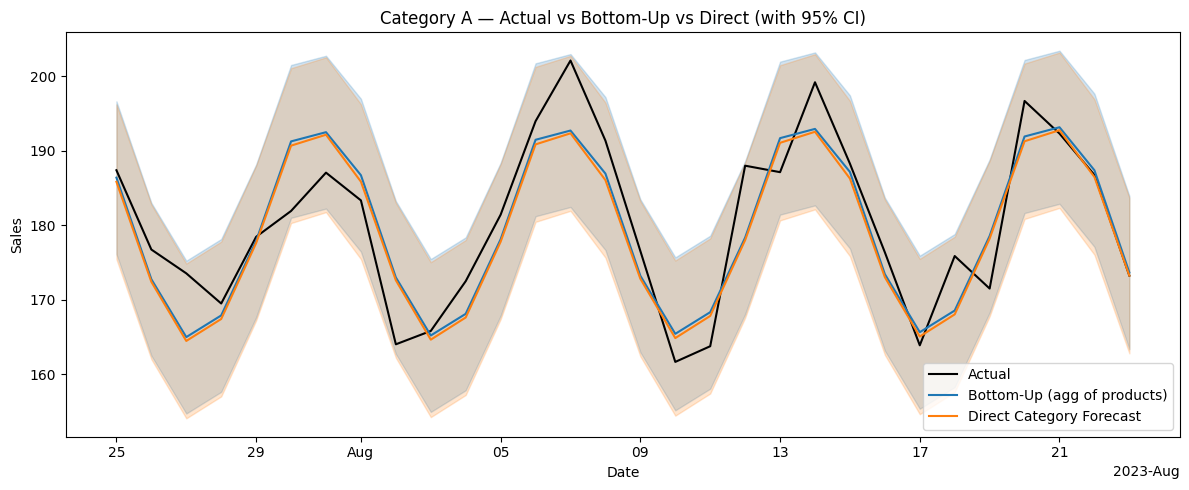

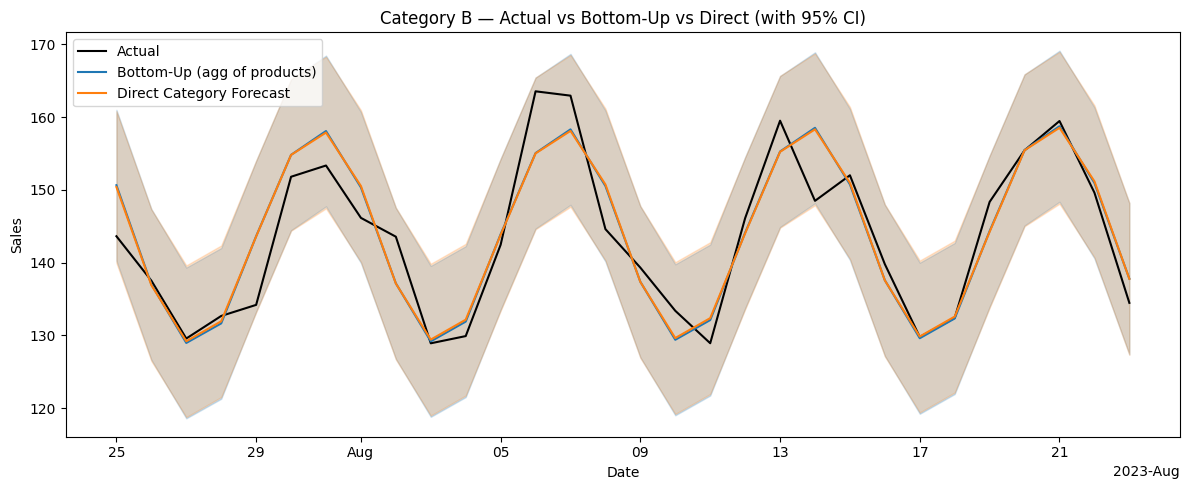

In [18]:
# Plotting function for aligned merged results (bottom-up vs direct with 95% CI)
# Call with the `merged` DataFrame returned by compare_category_metrics()
# Example: plot_category(merged_A, category='A')
def plot_category(merged, category='A', figsize=(12,5)):
    """
    merged: DataFrame with columns:
      'ds', 'actual', 'bottom_mean', 'bottom_lower', 'bottom_upper',
      'direct_mean', 'direct_lower', 'direct_upper'
    """
    plt.figure(figsize=figsize)
    ax = plt.gca()
    # actual
    plt.plot(merged['ds'], merged['actual'], label='Actual', color='black', linewidth=1.5)
    # bottom-up mean + CI
    plt.plot(merged['ds'], merged['bottom_mean'], label='Bottom-Up (agg of products)', color='tab:blue')
    plt.fill_between(merged['ds'], merged['bottom_lower'], merged['bottom_upper'], color='tab:blue', alpha=0.2)
    # direct category mean + CI
    plt.plot(merged['ds'], merged['direct_mean'], label='Direct Category Forecast', color='tab:orange')
    plt.fill_between(merged['ds'], merged['direct_lower'], merged['direct_upper'], color='tab:orange', alpha=0.2)
    # styling
    plt.title(f'Category {category} — Actual vs Bottom-Up vs Direct (with 95% CI)')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    # nice date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.tight_layout()
    plt.show()

# Example usage for categories A and B:
plot_category(merged_A, category='A')
plot_category(merged_B, category='B')

Hierarchical forecasting ensures coherence across aggregation levels. Modeling at the lowest level preserves granular dynamics, while aggregation guarantees consistency. The appropriate approach depends on business objectives, data structure, and volatility patterns.